# 2. Evaluate — simulated CRM data (`data/crm_simulated/`)

Same steps as `python -m src.evaluate --output reports/crm/simulated/final`, using the functions in `src/evaluate.py`.
Loads the models saved by `1_train.ipynb`; nothing here can change the selected model, threshold or calibration.

Simulated results describe the planted formula, not real sales. Step 6 is off by default (`RUN_CHECKS`) because it is very slow on 100,000 deals.

In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "train.py").is_file())
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src import evaluate, train


## Settings

Must match the settings used in `1_train.ipynb`.

In [2]:
DATA_DIR = ROOT / "data/crm_simulated"   # 100,000 simulated deals
QUICK = False            # True: tiny budgets, smoke test only (writes a *smoke* folder)
OUTPUT = train.default_output(DATA_DIR, QUICK)
RUN_CHECKS = False       # step 6 refits every model 7 times: very slow on 100,000 deals
print("Data:  ", DATA_DIR)
print("Output:", OUTPUT)

Data:   /Users/thaiphan/sources/miu/cs582-project/data/crm_simulated
Output: /Users/thaiphan/sources/miu/cs582-project/reports/crm/simulated/final


## 1. Load the saved models and rebuild the same split

In [3]:
ev = evaluate.start(OUTPUT)
print("Data:", ev.out.source_data())
print("Selected model:", ev.trained.selected, "| mode:", ev.manifest["mode"])
print("Test deals:", len(ev.split.test))

Data: /Users/thaiphan/sources/miu/cs582-project/data/crm_simulated
Selected model: tabnet | mode: full
Test deals: 14322


## 2. Test metrics

Each model uses its own validation threshold. The Dummy control shows what predicting the majority class gives.

In [4]:
COLUMNS = ["model", "roc_auc", "accuracy", "balanced_accuracy", "precision", "recall", "f1", "brier", "tn", "fp", "fn", "tp"]
evaluate.score_test(ev)[COLUMNS].round(4)

,model,roc_auc,accuracy,balanced_accuracy,precision,recall,f1,brier,tn,fp,fn,tp
0,dummy_prior,0.5000,0.6133,0.5000,0.6133,1.0000,0.7603,0.2373,0,5539,0,8783
1,logistic_regression,0.7837,0.7193,0.7134,0.7895,0.7395,0.7637,0.1814,3807,1732,2288,6495
2,random_forest,0.8400,0.7777,0.7641,0.8154,0.8240,0.8197,0.1548,3901,1638,1546,7237
3,mlp,0.8376,0.7550,0.7609,0.8455,0.7347,0.7862,0.1577,4360,1179,2330,6453
4,tabnet,0.8413,0.7826,0.7574,0.7955,0.8690,0.8306,0.1540,3577,1962,1151,7632


### Calibration of the selected model

Calibration changes the probability scale (Brier), not the ranking (ROC-AUC).

In [5]:
pd.read_csv(ev.out.metrics / "calibration_test.csv")[["variant", "roc_auc", "brier", "log_loss", "accuracy", "f1", "threshold"]].round(4)

,variant,roc_auc,brier,log_loss,accuracy,f1,threshold
0,raw,0.8413,0.1540,0.4743,0.7826,0.8306,0.5000
1,calibrated,0.8413,0.1541,0.4746,0.7826,0.8306,0.4872


## 3. Figures

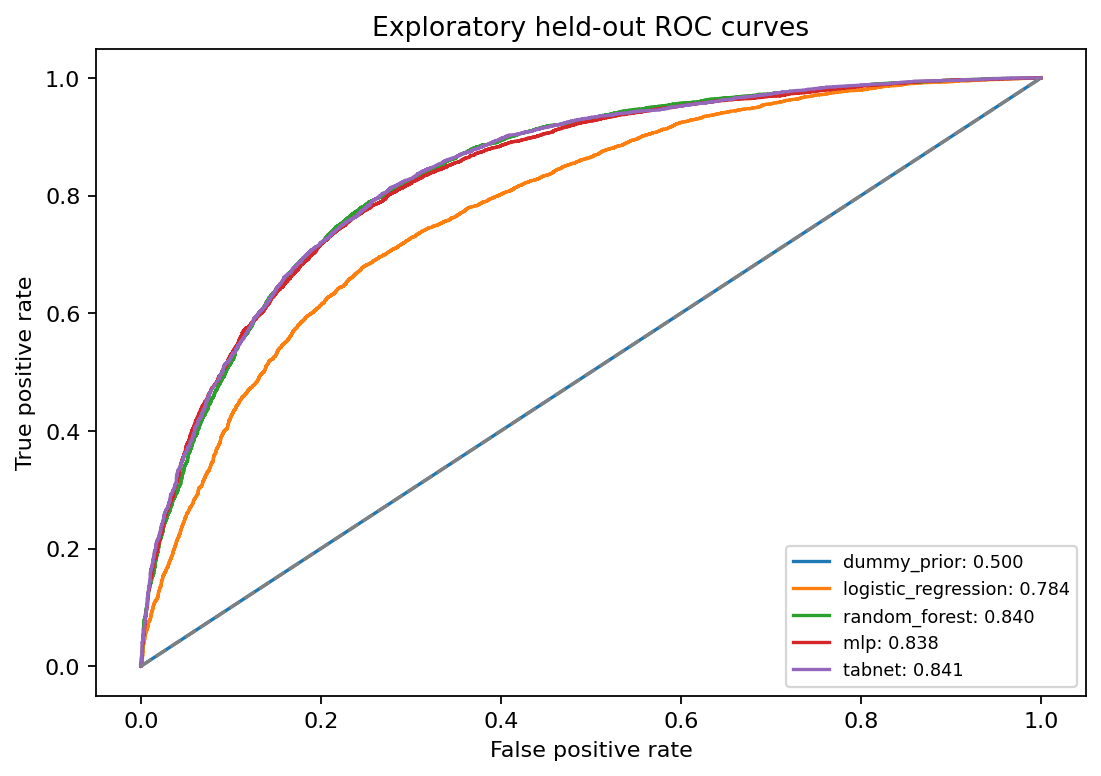

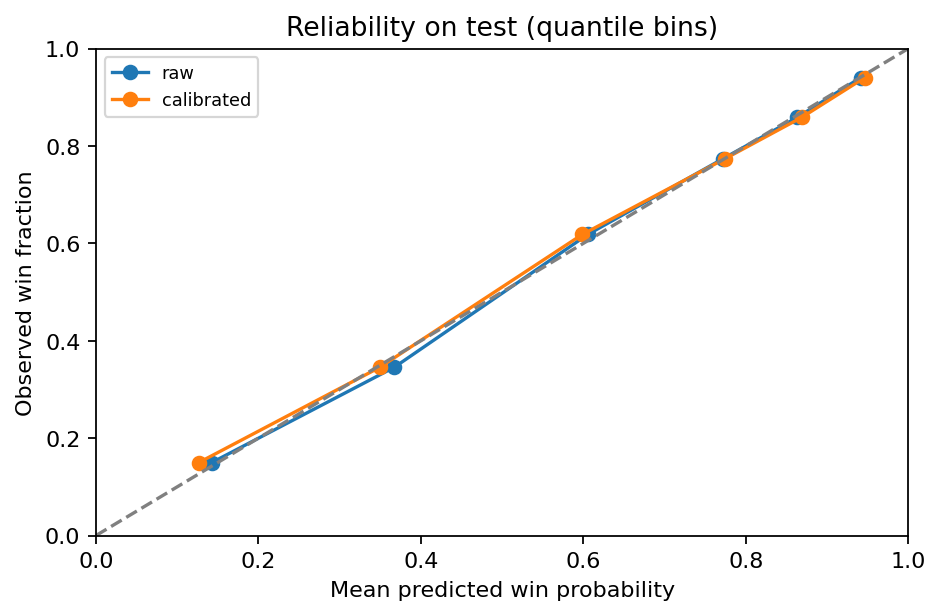

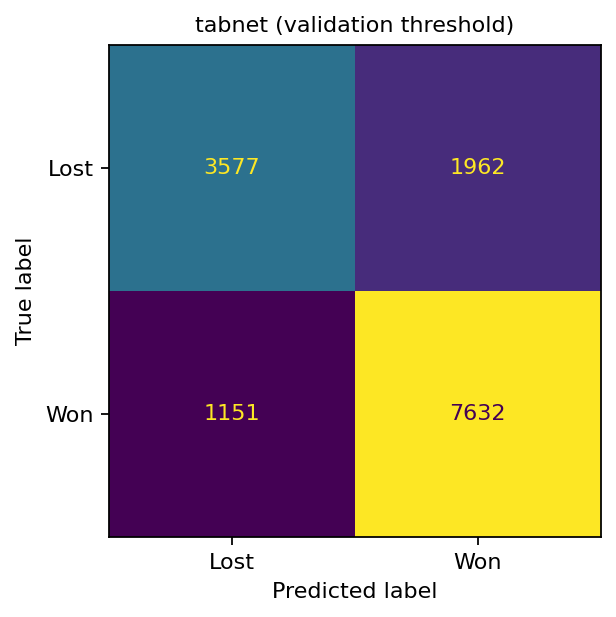

In [6]:
evaluate.make_figures(ev)
display(Image(filename=str(ev.out.figures / "roc_curves.png"), width=600))
display(Image(filename=str(ev.out.figures / "reliability.png"), width=500))
display(Image(filename=str(ev.out.figures / f"confusion_{ev.trained.selected}.png"), width=350))

## 4. Explanations

Permutation importance: ROC-AUC drop on test when one input is shuffled. TreeSHAP: raw Random Forest only.
Both describe the model's behaviour, not causes.

In [7]:
evaluate.explain_models(ev)
display(pd.read_csv(ev.out.explain / "permutation_importance_test.csv").head(10).round(4))
pd.read_csv(ev.out.explain / "rf_shap_global.csv").head(10).round(4)

/Users/thaiphan/sources/miu/cs582-project/.venv-crm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,feature,mean_auc_drop,std_auc_drop
0,product,0.1545,0.0021
1,sales_price,0.1093,0.0040
2,revenue,0.0734,0.0011
3,series,0.0654,0.0015
4,sector,0.0531,0.0023
5,sales_agent,0.0116,0.0006
6,regional_office,0.0075,0.0005
7,year_established,0.0010,0.0001
8,manager,0.0003,0.0001
9,office_location,0.0002,0.0002


,feature,mean_absolute_shap
0,sales_price,0.0799
1,revenue,0.0512
2,employees,0.0397
3,product_MG Advanced,0.0201
4,product_GTK 1000,0.0191
5,product_MG Elite,0.0183
6,product_GTX Basic,0.0143
7,product_GTX Lite,0.0142
8,series_MG,0.0137
9,product_GTX Pro,0.0102


## 5. Audits

The close-value model is deliberately invalid: it shows how an outcome field fakes a near-perfect score.

In [8]:
evaluate.run_audits(ev)
display(pd.read_csv(ev.out.checks / "leakage_audit.csv")[["model", "roc_auc", "accuracy", "purpose"]].round(4))
pd.read_csv(ev.out.checks / "priority_test.csv").round(4)

,model,roc_auc,accuracy,purpose
0,tabnet,0.8413,0.7826,Pre-close feature set; no outcome predictors
1,LEAKY_close_value_stump,1.0000,1.0000,Invalid future information; illustration only


,priority,count,observed_win_rate,mean_probability
0,Low,4019,0.2048,0.1967
1,Medium,3173,0.5796,0.5616
2,High,7130,0.8585,0.8639


## 6. Novelty checks

Compares the as-of split with a no-purge and a random split, and checks that the explanations describe the model.

In [9]:
if RUN_CHECKS:
    protocols, checks = evaluate.run_checks(ev)
    display(protocols[["protocol", "model", "roc_auc_mean", "roc_auc_sd", "delta_vs_asof"]].round(4))
    pd.json_normalize(checks, sep=".").T
else:
    print("Skipped (RUN_CHECKS = False)")

Skipped (RUN_CHECKS = False)


## 7. Record the stage

In [10]:
manifest = evaluate.finish(ev)

EVALUATED: tabnet test ROC-AUC 0.8413


Next: `3_predict.ipynb`.